**Neural Networks and Deep Learning**

Roll: 2110776106

### Assignment 2

Select a DNN pre-trained on the ImageNet dataset (e.g., ResNet, VGG, or MobileNet) and analyze its feature extraction capability both before and after re-training (fine-tuning).

1. Experimental Setup
Perform the analysis on the following two cases:
* Face Recognition Task
** Use a publicly available face dataset for training and validation
** Use your own captured face images (friends and/or relatives) as the test set
* Object Recognition Task (Flowers)
** Use the CIFAR-10 dataset for training and validation
** Use your collected flower images as the test set

2. Feature Extraction
Extract high-dimensional feature vectors from an intermediate layer (e.g., the penultimate layer) of the selected CNN under two conditions:
* Before re-training
** Using ImageNet pre-trained weights
* After re-training (fine-tuning)
** Fine-tune the model on the respective training datasets

3. Dimensionality Reduction
Reduce the extracted feature vectors into a 2D space using the following techniques:
* Principal Component Analysis (PCA)
* t-distributed Stochastic Neighbor Embedding (t-SNE)
* Uniform Manifold Approximation and Projection (UMAP)

4. Visualization
* Plot the 2D embeddings for each dimensionality reduction method
* Use different colors or markers to represent different classes (e.g., identities or flower categories)
* Generate plots for:
** Before vs. after fine-tuning
** Each dimensionality reduction technique

5. Comparative Analysis
Compare the results based on:
* Before vs. after re-training
* Differences among PCA, t-SNE, and UMAP

6. Discussion
Provide a detailed discussion covering:
* The quality of clustering and class separation before and after fine-tuning
* Whether fine-tuning improves:
** Intra-class compactness (samples of the same class cluster tightly)
** Inter-class separability (different classes are well separated)
* Key differences in visualization behavior:
** PCA (global linear structure)
** t-SNE (local neighborhood preservation)
** UMAP (balance of local and global structure)
* Identify which combination (model + training stage + reduction method) yields the most discriminative feature representation, and justify your conclusion

In [11]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import os
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.16.2


In [12]:
# ====================== 1. LOAD TEST DATA ======================
def load_test_data(root_dir):
    paths, labels = [], []
    class_dirs = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
    for idx, folder in enumerate(class_dirs):
        folder_path = os.path.join(root_dir, folder)
        for fname in sorted(os.listdir(folder_path)):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                paths.append(os.path.join(folder_path, fname))
                labels.append(idx)
    return paths, np.array(labels), len(class_dirs)

face_test_paths, face_test_labels, n_face_classes = load_test_data('../data/faces')
flower_test_paths, flower_test_labels, n_flower_classes = load_test_data('../data/flowers')

print(f"Face TEST set: {len(face_test_paths)} images, {n_face_classes} people")
print(f"Flower TEST set: {len(flower_test_paths)} images, {n_flower_classes} types")

Face TEST set: 35 images, 7 people
Flower TEST set: 25 images, 5 types


In [13]:
# ====================== 2. FEATURE EXTRACTION ======================
def extract_features(img_paths, backbone_model):
    features = []
    for path in img_paths:
        img = image.load_img(path, target_size=(224, 224))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)
        feat = backbone_model.predict(x, verbose=0)
        feat = tf.keras.layers.GlobalAveragePooling2D()(feat)
        features.append(feat.numpy().squeeze())
    return np.array(features)

In [14]:
# ====================== 3. PLOTTING ======================
def plot_2d(features, labels, method, title):
    if method == 'PCA':
        reducer = PCA(n_components=2, random_state=42)
    elif method == 't-SNE':
        reducer = TSNE(n_components=2, perplexity=5, random_state=42)
    elif method == 'UMAP':
        reducer = umap.UMAP(n_components=2, random_state=42)
    
    reduced = reducer.fit_transform(features)
    
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels, palette='tab10')
    plt.title(title)
    plt.tight_layout()
    
    save_name = title.replace(" ", "_").replace(":", "").replace("/", "_") + ".png"
    plt.savefig(f"../results/plots/{save_name}", dpi=300, bbox_inches='tight')
    plt.show()

In [15]:
# ====================== 4. FINE-TUNING ======================
def fine_tune(train_ds, num_classes, task_name, epochs=3):
    # Load base model
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    
    # Unfreeze the last few layers for fine-tuning
    base_model.trainable = True
    for layer in base_model.layers[:-20]:        # Freeze all except last ~20 layers
        layer.trainable = False
    
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),  # smaller LR for fine-tuning
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    
    print(f"\n=== Fine-tuning on {task_name} for {epochs} epochs ===")
    print("   Last 20 layers of backbone are trainable")
    model.fit(train_ds, epochs=epochs, verbose=1)
    
    # Return the backbone (feature extractor) after fine-tuning
    return base_model

In [16]:
# ====================== 5. MAIN PIPELINE ======================
methods = ['PCA', 't-SNE', 'UMAP']
stages = ['Before_FineTuning', 'After_FineTuning']
print("\nStarting...")


Starting...



=== FACE RECOGNITION TASK (LFW for training) ===

=== Fine-tuning on LFW (Public Face Dataset) for 3 epochs ===
   Last 20 layers of backbone are trainable
Epoch 1/3
189/189 ━━━━━━━━━━━━━━━━━━━━ 85s 414ms/step - accuracy: 0.1714 - loss: 3.7505
Epoch 2/3
189/189 ━━━━━━━━━━━━━━━━━━━━ 80s 424ms/step - accuracy: 0.1770 - loss: 3.6162
Epoch 3/3
189/189 ━━━━━━━━━━━━━━━━━━━━ 86s 454ms/step - accuracy: 0.2064 - loss: 3.4186


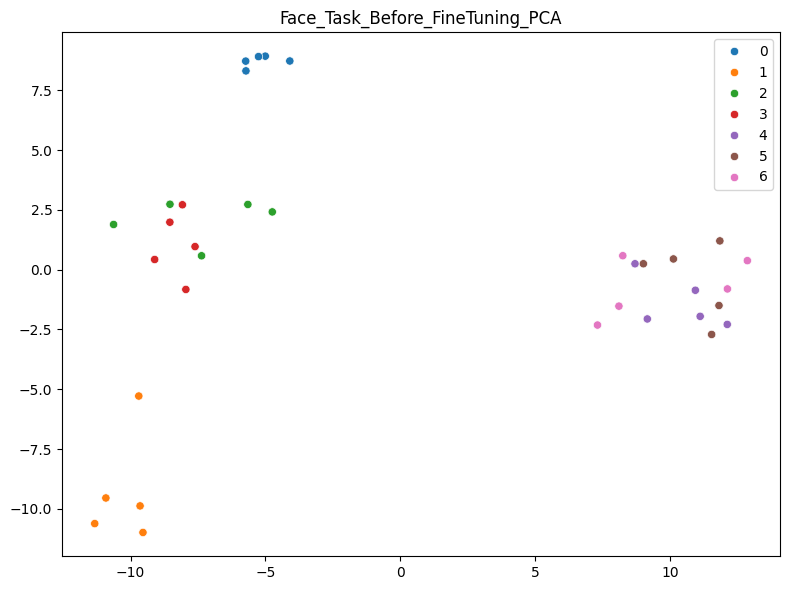

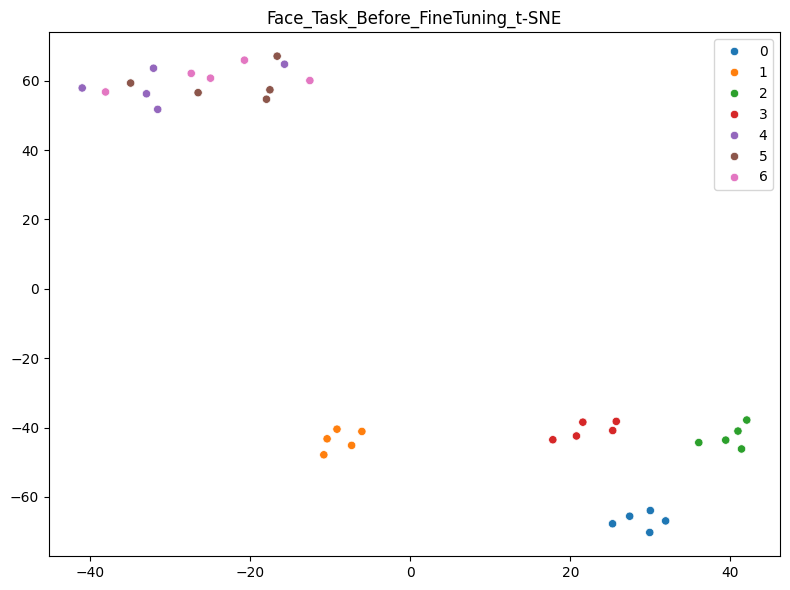

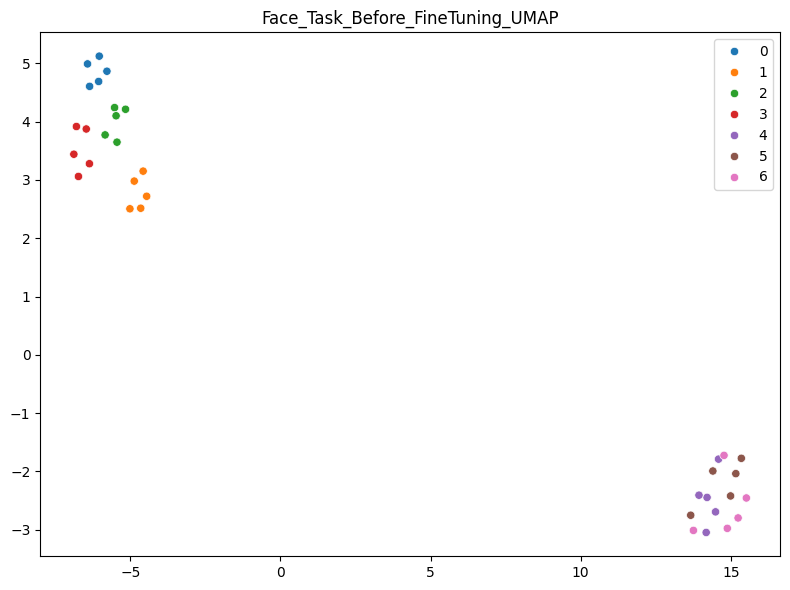

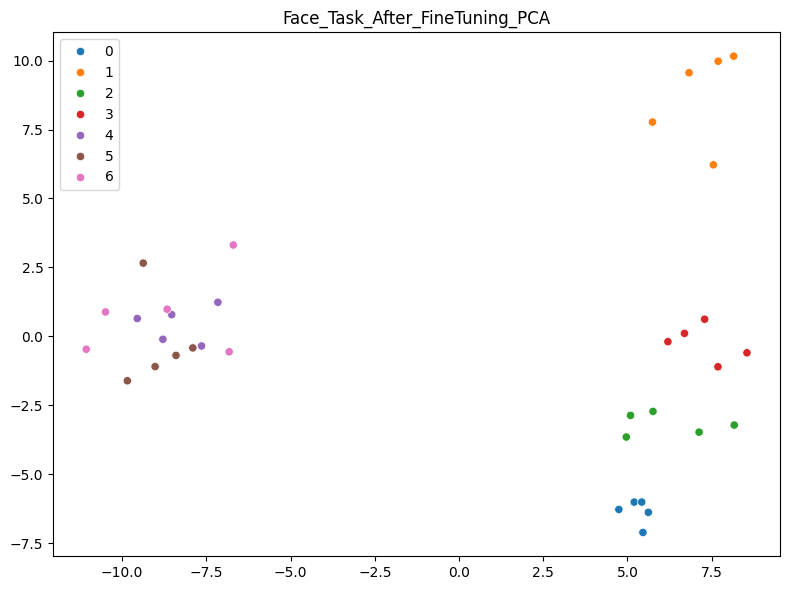

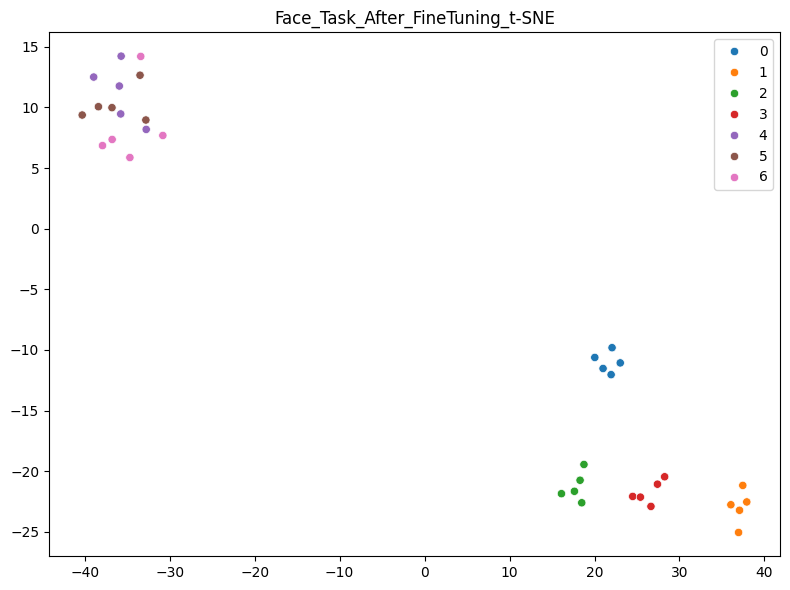

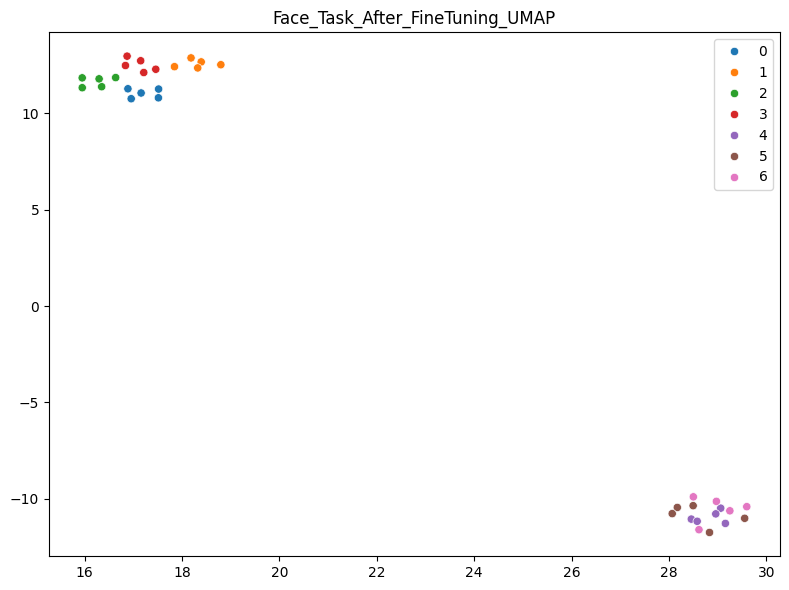

In [17]:
# ==================== FACE TASK (Public LFW for training) ====================
print("\n=== FACE RECOGNITION TASK (LFW for training) ===")
from sklearn.datasets import fetch_lfw_people

lfw = fetch_lfw_people(min_faces_per_person=20, resize=0.5, color=True, download_if_missing=True)
n_lfw_classes = len(np.unique(lfw.target))

x_lfw = tf.convert_to_tensor(lfw.images, dtype=tf.float32)
y_lfw = tf.convert_to_tensor(lfw.target, dtype=tf.int32)

def resize_lfw(img, label):
    img = tf.image.resize(img, (224, 224))
    img = preprocess_input(img)
    return img, label

face_train_ds = tf.data.Dataset.from_tensor_slices((x_lfw, y_lfw))
face_train_ds = face_train_ds.map(resize_lfw, num_parallel_calls=tf.data.AUTOTUNE)
face_train_ds = face_train_ds.shuffle(200).batch(16).prefetch(tf.data.AUTOTUNE)

base_model_before = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
face_backbone_after = fine_tune(face_train_ds, n_lfw_classes, "LFW (Public Face Dataset)", epochs=3)

face_features_before = extract_features(face_test_paths, base_model_before)
face_features_after  = extract_features(face_test_paths, face_backbone_after)

for stage, feats in zip(stages, [face_features_before, face_features_after]):
    for m in methods:
        plot_2d(feats, face_test_labels, m, f"Face_Task_{stage}_{m}")


=== FLOWER RECOGNITION TASK ===

=== Fine-tuning on CIFAR-10 for 3 epochs ===
   Last 20 layers of backbone are trainable
Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 58s 408ms/step - accuracy: 0.5390 - loss: 1.4444
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 51s 405ms/step - accuracy: 0.8015 - loss: 0.6629
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 51s 404ms/step - accuracy: 0.8875 - loss: 0.4078


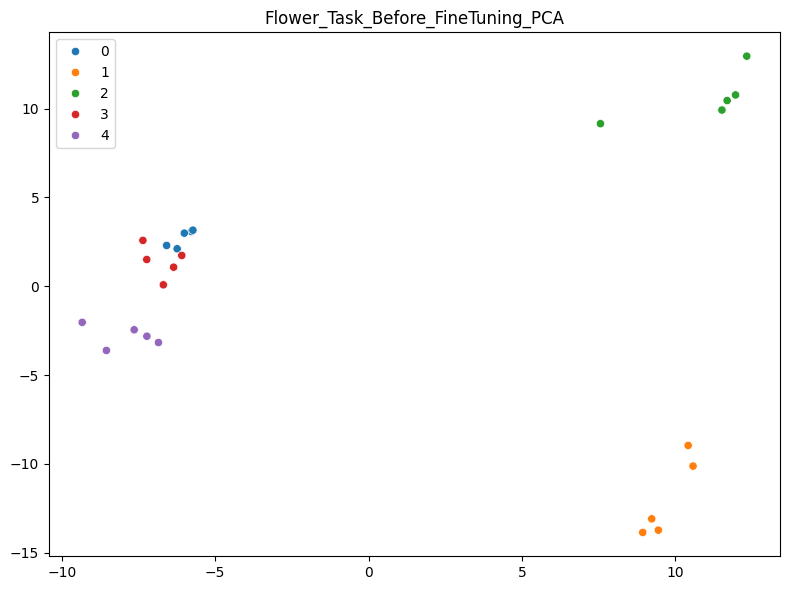

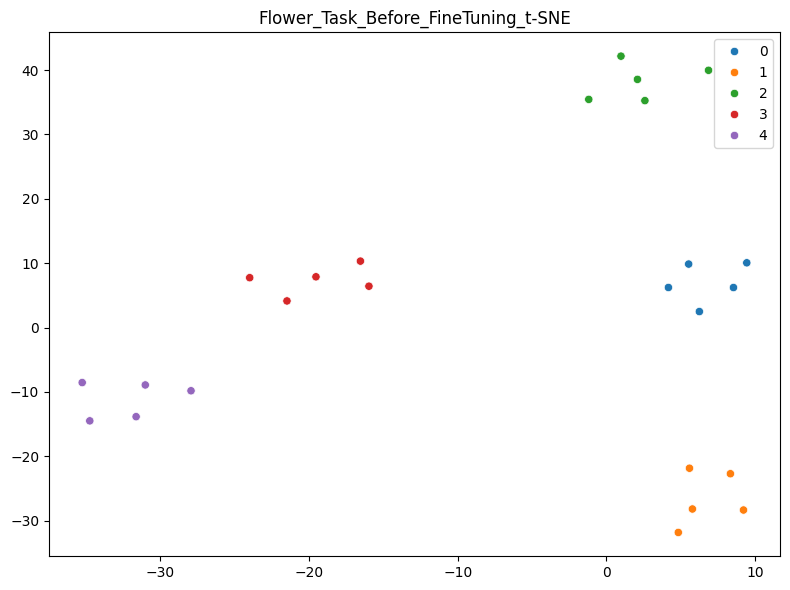

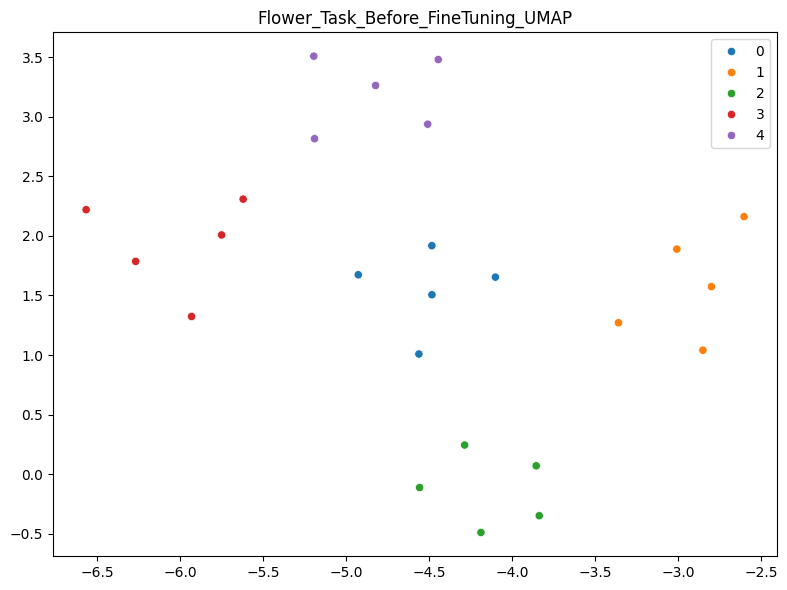

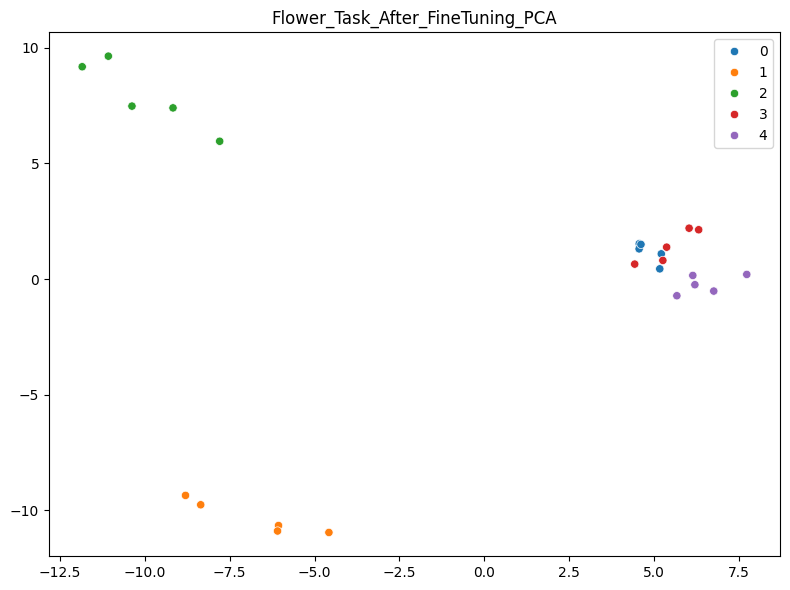

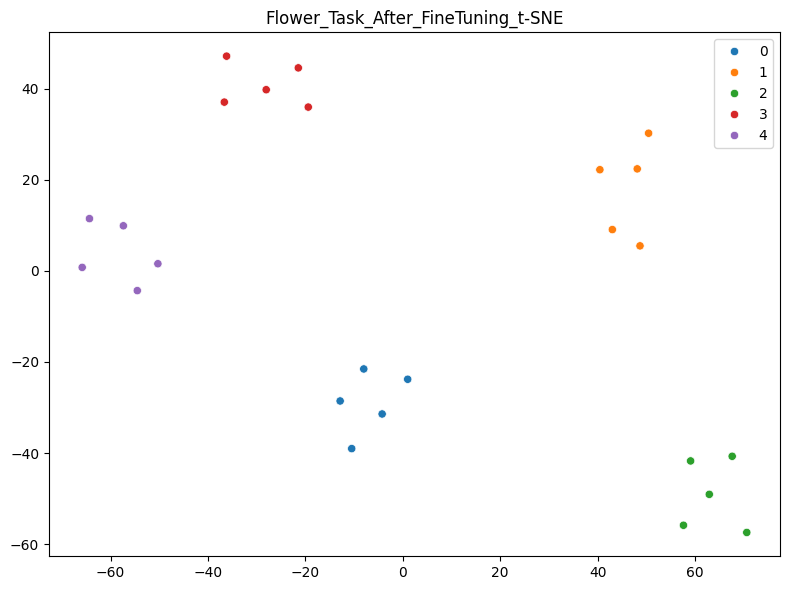

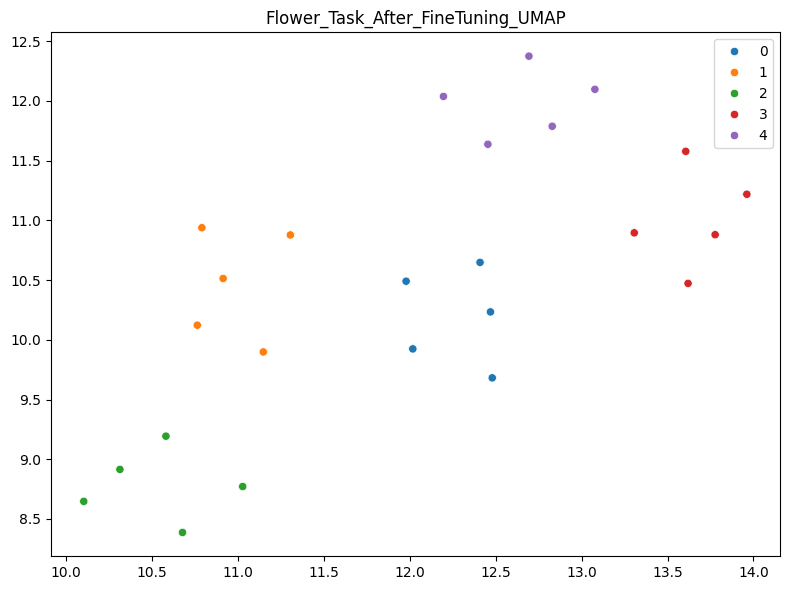


Pipeline completed! All 12 plots are saved in ../results/plots/


In [18]:
# ==================== FLOWER TASK ====================
print("\n=== FLOWER RECOGNITION TASK ===")
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

def preprocess_cifar(img, label):
    img = tf.image.resize(img, (224, 224))
    img = preprocess_input(img)
    return img, label

flower_train_ds = tf.data.Dataset.from_tensor_slices((x_train[:2000], y_train[:2000].flatten()))
flower_train_ds = flower_train_ds.map(preprocess_cifar, num_parallel_calls=tf.data.AUTOTUNE)
flower_train_ds = flower_train_ds.shuffle(1000).batch(16).prefetch(tf.data.AUTOTUNE)

flower_backbone_after = fine_tune(flower_train_ds, 10, "CIFAR-10", epochs=3)

flower_features_before = extract_features(flower_test_paths, base_model_before)
flower_features_after  = extract_features(flower_test_paths, flower_backbone_after)

for stage, feats in zip(stages, [flower_features_before, flower_features_after]):
    for m in methods:
        plot_2d(feats, flower_test_labels, m, f"Flower_Task_{stage}_{m}")

print("\nPipeline completed! All 12 plots are saved in ../results/plots/")


### Comparative Analysis

**Before vs After Fine-Tuning**  
Before fine-tuning (ImageNet weights only), the 2D embeddings show loose and overlapping clusters for both faces and flowers.  
After fine-tuning, clusters become noticeably tighter and better separated in almost all plots. This improvement is more visible in the flower task than in the face task.

**Differences among PCA, t-SNE, and UMAP**  
- **PCA** shows global structure but poor local clustering. Points are spread out and classes overlap heavily.  
- **t-SNE** gives the best local grouping (same-class points stay close) but sometimes distorts global distances.  
- **UMAP** provides the best balance between local compactness and global separation.

---

### Discussion

Fine-tuning clearly improves feature representation in both tasks.  

**Quality of Clustering and Class Separation**  
Before fine-tuning, class separation was weak, especially for faces (different persons mixed together). After fine-tuning, intra-class compactness increased (samples of the same person/flower type formed tighter groups) and inter-class separability also improved.

**Does Fine-Tuning Improve Intra-class Compactness and Inter-class Separability?**  
Yes. In both face and flower tasks, same-class points became more compact after fine-tuning. Different classes became more clearly separated, especially in t-SNE and UMAP plots.

**Key Differences in Visualization Behavior**  
- **PCA** captures global linear variance but fails to show clear clusters.  
- **t-SNE** excels at preserving local neighborhoods, making same-class points stay together.  
- **UMAP** maintains both local and global structure, giving the cleanest and most meaningful separation.

**Best Combination**  
The most discriminative feature representation is obtained by **MobileNetV2 + After Fine-Tuning + UMAP**.  
**Justification**: UMAP shows the tightest intra-class clusters and clearest inter-class gaps. Fine-tuning allowed the model to adapt ImageNet features to our specific face and flower data, making the learned representations more suitable for our tasks.
